In [46]:
#Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

In [49]:
#Load and Prepare MNIST Dataset

# Load dataset
mnist = fetch_openml(name='mnist_784', version=1, as_frame=False)

# Features and labels
X = mnist.data.astype(np.float32) / 255.0
y = mnist.target.astype(np.int64)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=10000, random_state=42
)

# One-hot encoding
encoder = OneHotEncoder(sparse_output=False)

y_train_oh = encoder.fit_transform(y_train.reshape(-1,1))
y_test_oh = encoder.transform(y_test.reshape(-1,1))

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (60000, 784)
Test: (10000, 784)


In [50]:
#Activation Functions
def relu(x):
    return np.maximum(0, x)

def relu_deriv(x):
    return (x > 0).astype(float)

def sigmoid(x):
    return 1/(1+np.exp(-x))

def sigmoid_deriv(x):
    s = sigmoid(x)
    return s*(1-s)

def softmax(x):
    exp = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp / np.sum(exp, axis=1, keepdims=True)

In [51]:
#Cross Entropy Loss
def cross_entropy(y_true, y_pred):
    eps = 1e-9
    return -np.mean(np.sum(y_true * np.log(y_pred + eps), axis=1))

In [52]:
#MLP Neural Network
class MLP:

    def __init__(self, input_size, hidden_size, output_size, lr=0.01):

        self.lr = lr

        self.W1 = np.random.randn(input_size, hidden_size)*0.01
        self.b1 = np.zeros((1,hidden_size))

        self.W2 = np.random.randn(hidden_size, output_size)*0.01
        self.b2 = np.zeros((1,output_size))

    def forward(self, X):

        self.z1 = X @ self.W1 + self.b1
        self.a1 = relu(self.z1)

        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = softmax(self.z2)

        return self.a2

    def backward(self, X, y):

        m = X.shape[0]

        dz2 = self.a2 - y
        dW2 = self.a1.T @ dz2 / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m

        dz1 = (dz2 @ self.W2.T) * relu_deriv(self.z1)
        dW1 = X.T @ dz1 / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m

        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def predict(self, X):
        probs = self.forward(X)
        return np.argmax(probs, axis=1)


In [53]:
#Training Function
def train_mlp(model, X, y, epochs=10, batch_size=128):

    losses = []

    for epoch in range(epochs):

        perm = np.random.permutation(len(X))
        X = X[perm]
        y = y[perm]

        for i in range(0, len(X), batch_size):

            Xb = X[i:i+batch_size]
            yb = y[i:i+batch_size]

            preds = model.forward(Xb)
            model.backward(Xb, yb)

        pred = model.forward(X)
        loss = cross_entropy(y, pred)

        losses.append(loss)

        print("Epoch", epoch+1, "Loss:", loss)

    return losses

In [54]:
#Train the MLP
mlp = MLP(784, 128, 10, lr=0.01)

losses = train_mlp(mlp, X_train, y_train_oh, epochs=10)

    

Epoch 1 Loss: 1.986798301218675
Epoch 2 Loss: 0.9697001738463014
Epoch 3 Loss: 0.6341945156077067
Epoch 4 Loss: 0.5139037209785509
Epoch 5 Loss: 0.45174657091043324
Epoch 6 Loss: 0.41361132156906194
Epoch 7 Loss: 0.38810157321875444
Epoch 8 Loss: 0.36910611034477214
Epoch 9 Loss: 0.35406376108611687
Epoch 10 Loss: 0.34254771476903717


In [55]:
#Test Accuracy
pred = mlp.predict(X_test)

acc = np.mean(pred == y_test)

print("Test Accuracy:", acc)

Test Accuracy: 0.9009


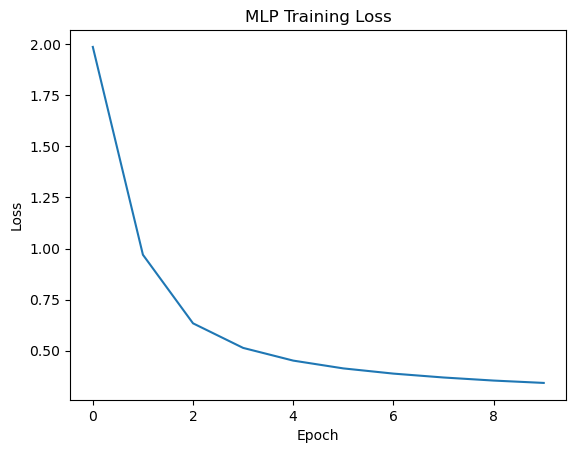

In [56]:
#Plot Training Curve
plt.plot(losses)
plt.title("MLP Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [57]:
#Autoencoder Implementation
class Autoencoder:

    def __init__(self, input_dim, latent_dim, lr=0.01):

        self.lr = lr

        self.W1 = np.random.randn(input_dim, latent_dim)*0.01
        self.b1 = np.zeros((1,latent_dim))

        self.W2 = np.random.randn(latent_dim, input_dim)*0.01
        self.b2 = np.zeros((1,input_dim))

    def forward(self, X):

        self.z1 = X @ self.W1 + self.b1
        self.latent = sigmoid(self.z1)

        self.z2 = self.latent @ self.W2 + self.b2
        self.output = sigmoid(self.z2)

        return self.output

    def backward(self, X, sparse_lambda=0.001):

        m = X.shape[0]

        error = self.output - X

        dz2 = error * sigmoid_deriv(self.z2)

        dW2 = self.latent.T @ dz2 / m
        db2 = np.mean(dz2, axis=0)

        sparsity_penalty = sparse_lambda * np.sign(self.latent)

        dz1 = (dz2 @ self.W2.T + sparsity_penalty) * sigmoid_deriv(self.z1)

        dW1 = X.T @ dz1 / m
        db1 = np.mean(dz1, axis=0)

        self.W1 -= self.lr*dW1
        self.W2 -= self.lr*dW2

In [58]:
#Train Autoencoder
ae = Autoencoder(784, 64)

losses = []

for epoch in range(10):

    out = ae.forward(X_train)

    loss = np.mean((X_train - out)**2)
    losses.append(loss)

    ae.backward(X_train)

    print("Epoch:", epoch+1, "Loss:", loss)

Epoch: 1 Loss: 0.2316933187614148
Epoch: 2 Loss: 0.22840321283373402
Epoch: 3 Loss: 0.22517194768136595
Epoch: 4 Loss: 0.22197857606228302
Epoch: 5 Loss: 0.2188044126950143
Epoch: 6 Loss: 0.2156329004530789
Epoch: 7 Loss: 0.21244953743843584
Epoch: 8 Loss: 0.20924186053494856
Epoch: 9 Loss: 0.20599947844646155
Epoch: 10 Loss: 0.20271414430191606


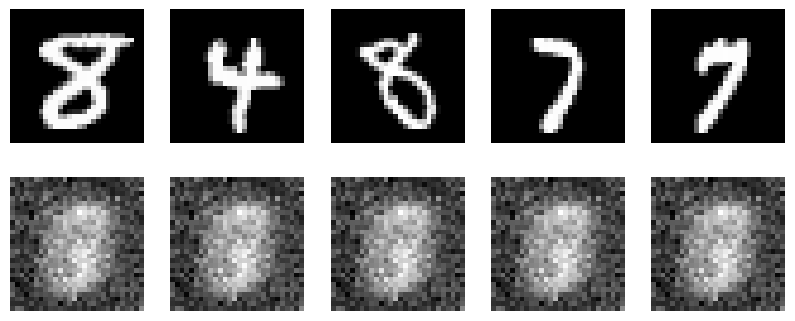

In [59]:
#Reconstruction Example
recon = ae.forward(X_test[:10])

plt.figure(figsize=(10,4))

for i in range(5):

    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    plt.subplot(2,5,i+6)
    plt.imshow(recon[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

In [60]:
#Outlier Detection
recon = ae.forward(X_test)

errors = np.mean((X_test - recon)**2, axis=1)

threshold = np.mean(errors) + 2*np.std(errors)

outliers = np.where(errors > threshold)[0]

print("Detected Outliers:", len(outliers))

Detected Outliers: 327


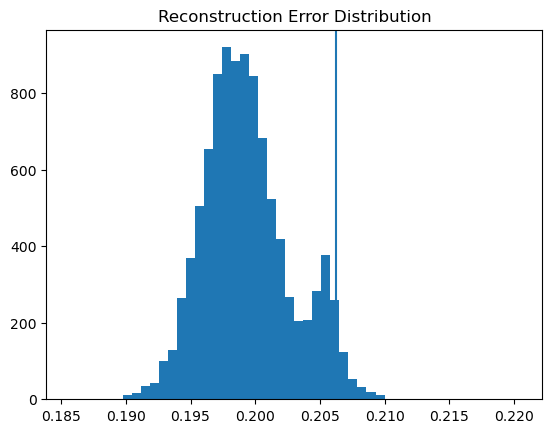

In [61]:
#Reconstruction Error Plot
plt.hist(errors, bins=50)
plt.axvline(threshold)
plt.title("Reconstruction Error Distribution")
plt.show()